## Importación de Librerías

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import cophenet
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sb

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

# Agrupación de los Clientes

## Visualización de los datos

### Se carga la base de datos

In [156]:
df = pd.read_csv(r"mallCustomers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Distribución de los datos

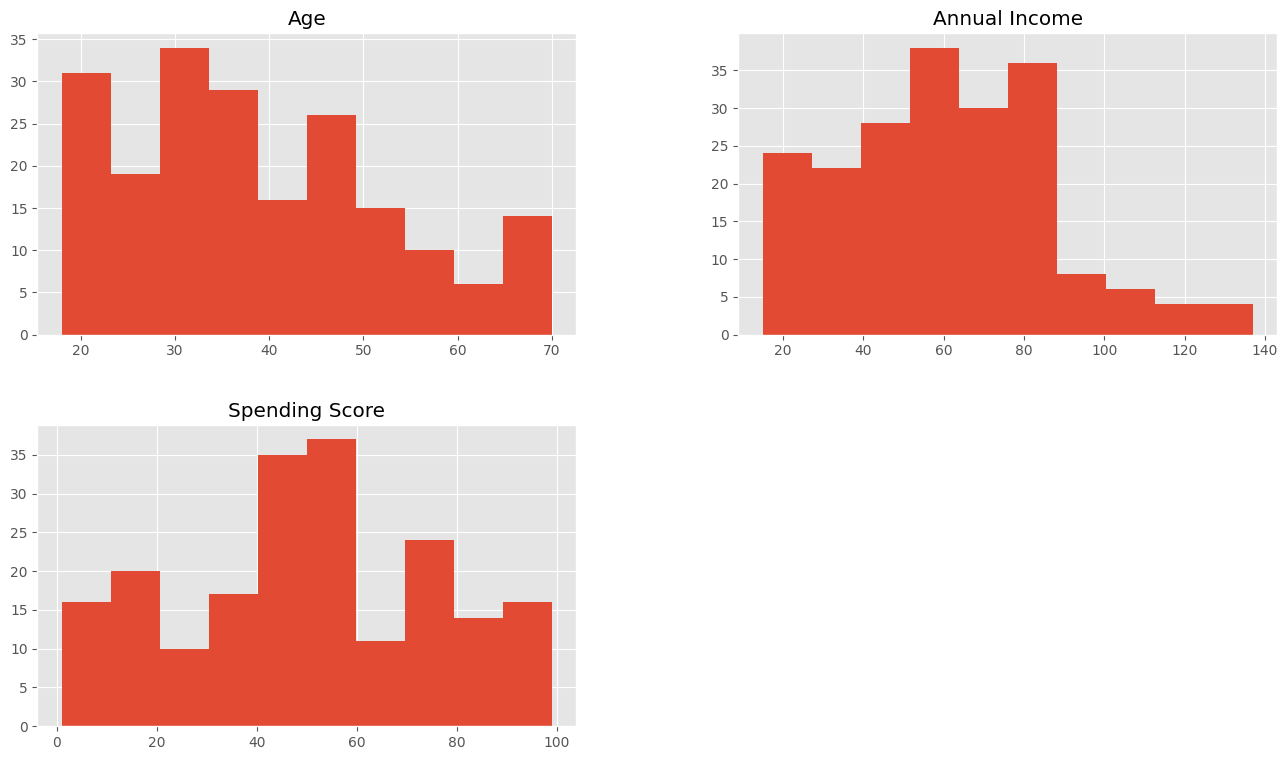

In [157]:
df.drop('CustomerID', axis = 1).hist()
plt.show()

# Tratamiento de datos

### Quitar columna ID

In [158]:
df = df.drop('CustomerID', axis = 1)

### Quitar columna género (Para separa para el apartado 'c') 

In [159]:
df = df.drop('Genre', axis = 1)

### Comprobación de outlayers

Text(0.5, 1.0, 'Violinplot variables')

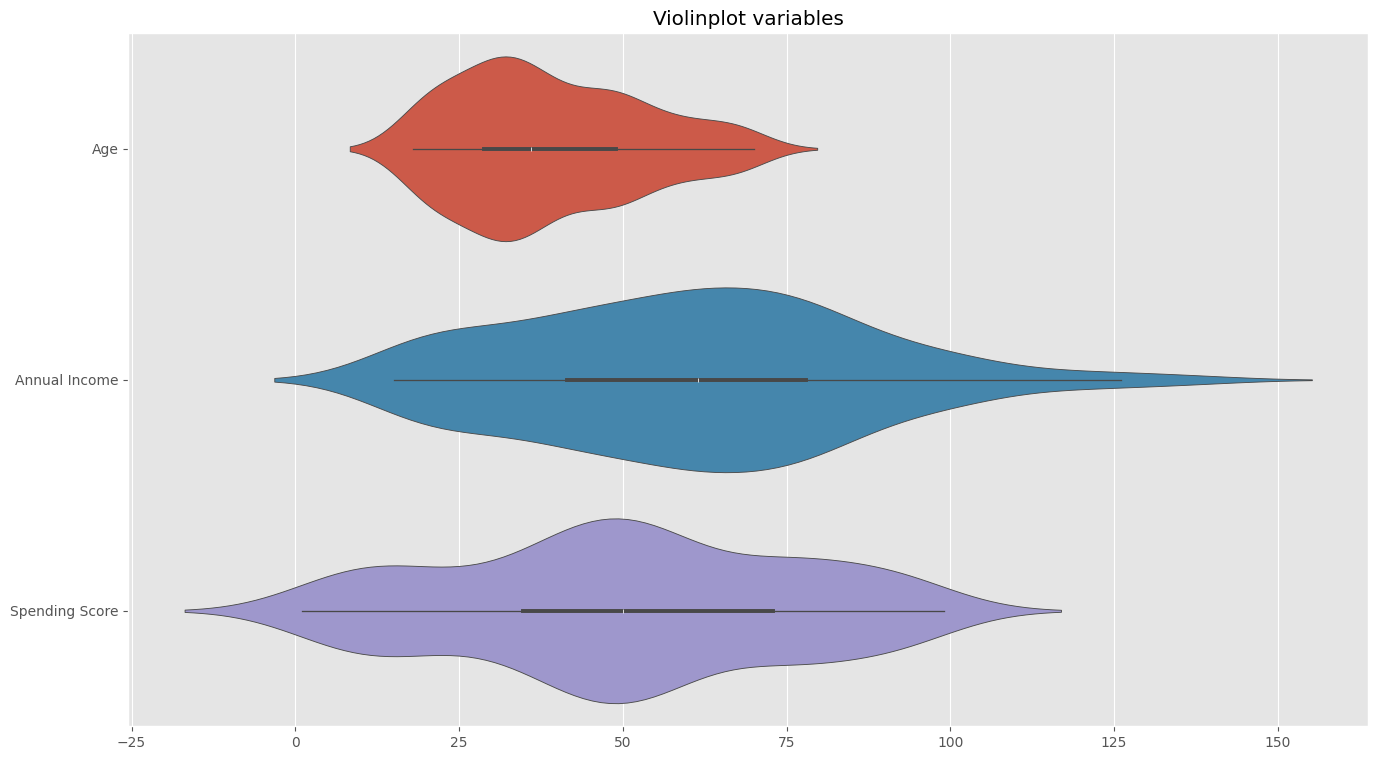

In [160]:
sb.violinplot(data=df, orient='h').set_title("Violinplot variables")

### Eliminación de outlayers

In [161]:
df = df[df['Annual Income'] <= 135]

### Visualización de los datos

In [162]:
df.head()

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Normalización de los datos

In [163]:
df = (df - df.min()) / (df.max() - df.min())

### Estandatización de los datos

In [164]:
df_mean = df.mean()
df_std = df.std()
df = (df - df_mean) / df_std

## Resultados

In [165]:
df.head()

,Age,Annual Income,Spending Score
0,-1.421809,-1.774673,-0.434887
1,-1.279124,-1.774673,1.196381
2,-1.350467,-1.735049,-1.716597
3,-1.136439,-1.735049,1.041022
4,-0.565697,-1.695425,-0.396047


# Agrupamiento de datos

### Visualización de los datos

In [166]:
fig = px.scatter_3d(df, x = 'Age', y = 'Annual Income', z = 'Spending Score')
fig.show()

## K-means

### Se define K-menas

In [167]:
Nc = range(1, 20)
kmeans = [KMeans(n_clusters = i) for i in Nc]
kmeans
score = [kmeans[i].fit(df).score(df) for i in range(len(kmeans))]
score

[-591.0,
 -383.33459207612015,
 -329.06628159363424,
 -257.5819577216523,
 -163.45786205724136,
 -157.89020620487435,
 -114.8450393185995,
 -99.87032915235942,
 -90.92205863422339,
 -78.87733302743112,
 -71.84452323793096,
 -66.24230852274209,
 -63.17370580827699,
 -59.259170188115974,
 -54.874157766221984,
 -55.783502861981134,
 -54.127076858931495,
 -49.64958523393177,
 -50.07428025229582]

### Muestra de gráfica para ver el codo

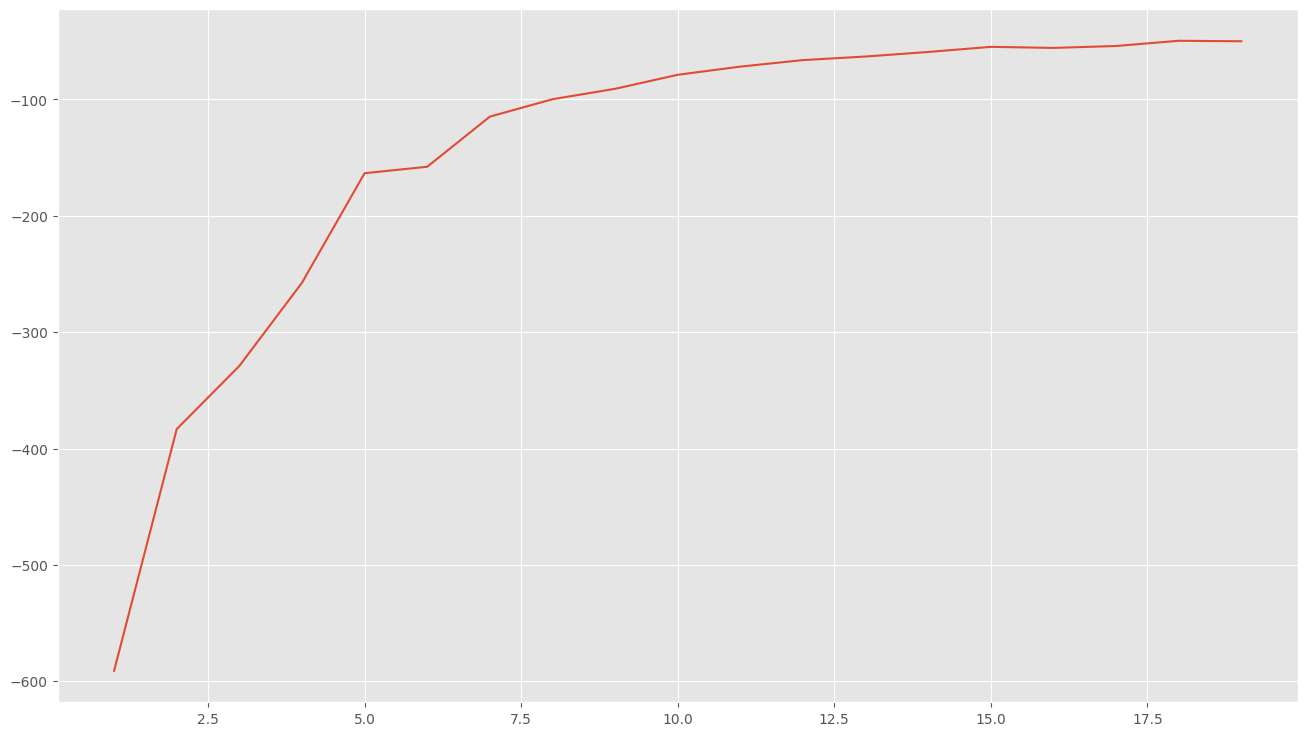

In [168]:
plt.plot(Nc, score)

## Elección de clusters

In [169]:
kmeans = KMeans(n_clusters = 8).fit(df)
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.89565711  0.64734135 -1.53696376]
 [-1.0222904  -0.15537393 -0.01541819]
 [ 0.58247438 -0.16742622 -0.09261211]
 [-0.4399087   1.00734583  1.23930881]
 [-0.97591764 -1.34541336  1.03778524]
 [ 0.46163769 -1.35267775 -1.22915907]
 [ 0.50444331  1.19864771 -1.20869353]
 [ 1.84925314 -0.26301901 -0.0134762 ]]


## Visualización en diseño 3D

In [170]:
df['Cluster_kmeans'] = kmeans.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'black', 'orange']

fig = go.Figure()

for i in df['Cluster_kmeans'].unique():
  df_cluster = df[df['Cluster_kmeans'] == i]
  fig.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

fig.show()

## Denogramas

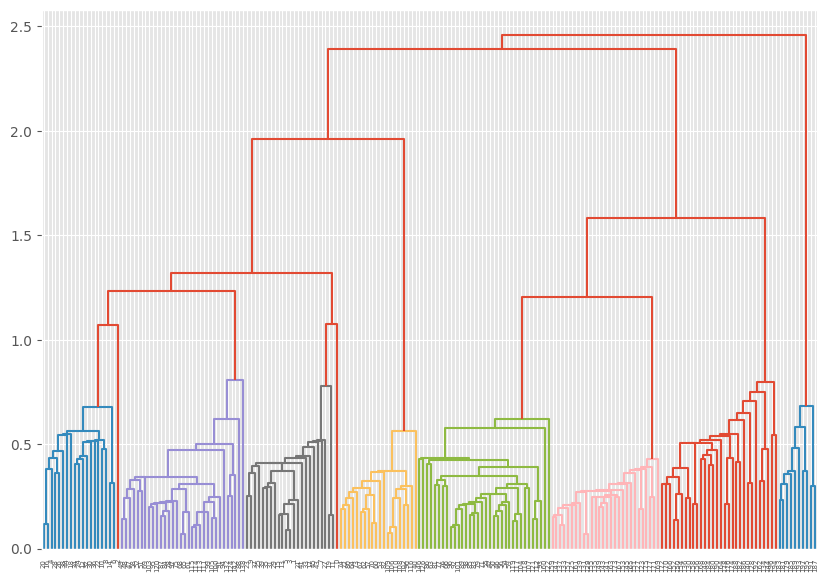

In [171]:
linked = linkage(df, 'single')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold = 1)
plt.show()

### Calcular calidad del denogramas

In [172]:
c, coph_dists = cophenet(linked, pdist(df))

print(c)

0.8318203269580879


## Método Centroid

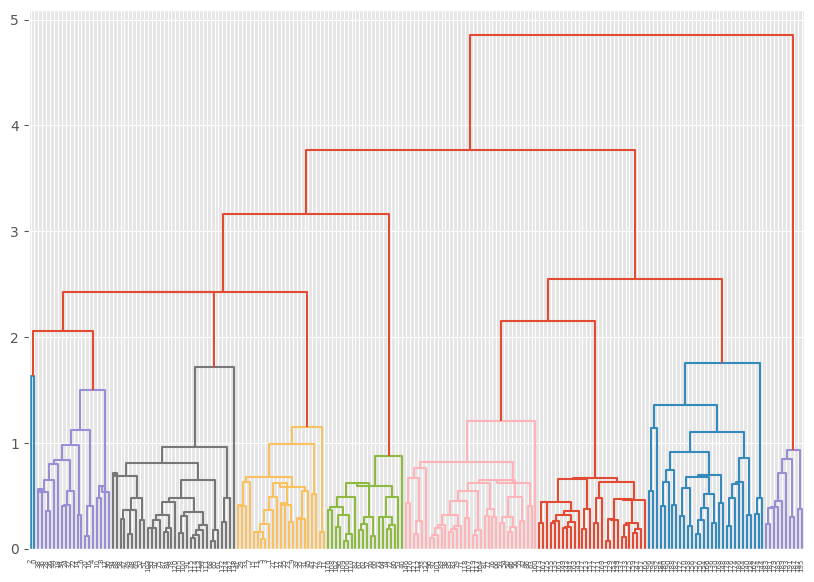

In [173]:
linked = linkage(df, 'centroid')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold=2)
plt.show()

### Calidad del Denograma

In [174]:
c, coph_dists = cophenet(linked, pdist(df))
print(c)

0.8422474654184617


## Método Ward

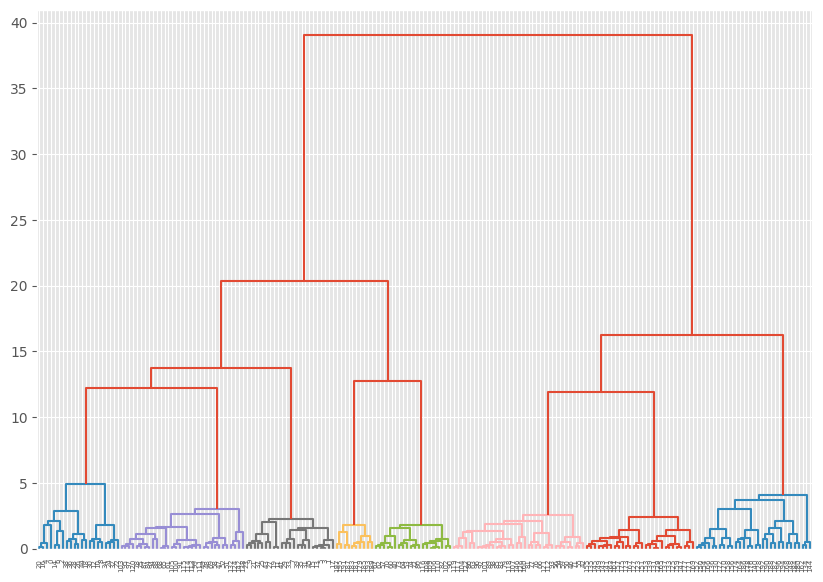

In [175]:
linked = linkage(df, 'ward')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold=5)
plt.show()

### Calcular calidad del Denograma

In [176]:
c, coph_dists = cophenet(linked, pdist(df))

print(c)

0.7955001143293072


# Agrupamiento por género

## Se repite la parte de tratamiento de datos

In [178]:
df = pd.read_csv(r"mallCustomers.csv")

# Quitamos CustomerID
df = df.drop('CustomerID', axis = 1)
df.head()

,Genre,Age,Annual Income,Spending Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Se crea un df para cada género

In [180]:
df_female = df[df['Genre'] == 'Female']
df_female = df_female.drop('Genre', axis = 1)
df_male = df[df['Genre'] == 'Male']
df_male = df_male.drop('Genre', axis = 1)

### Se quitan outlayers

In [181]:
df_female = df_female[df_female['Annual Income'] < 135]
df_male = df_male[df_male['Annual Income'] < 135]

### Estándarización de los datos

In [182]:
# Estandarización female
df_female_mean = df_female.mean()
df_female_std = df_female.std()
df_female = (df_female - df_female_mean) / df_female_std

# Estandarización male
df_male_mean = df_male.mean()
df_male_std = df_male.std()
df_male = (df_male - df_male_mean) / df_male_std

## K-means

### Creación de clusters (female)

In [ ]:
kmeans_female = KMeans(n_clusters = 6).fit(df_female)
centroids_female = kmeans_female.cluster_centers_

### Visualización en 3D (female)

In [211]:
df_female['Cluster_female'] = kmeans.fit_predict(df_female[['Age', 'Annual Income', 'Spending Score']])

colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'brown', 'orange']

fig_female = go.Figure()

for i in df_female['Cluster_female'].unique():
  df_cluster = df_female[df_female['Cluster_female'] == i]
  fig_female.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

fig_female.add_trace(go.Scatter3d(
  x = centroids_female[:, 0], 
  y = centroids_female[:, 1], 
  z = centroids_female[:, 2], 
  mode = 'markers',
  marker = dict(
    size = 5,
    color = 'black',                
    opacity = 0.8
  ),
  name = 'Centroids'
))

fig_female.show()

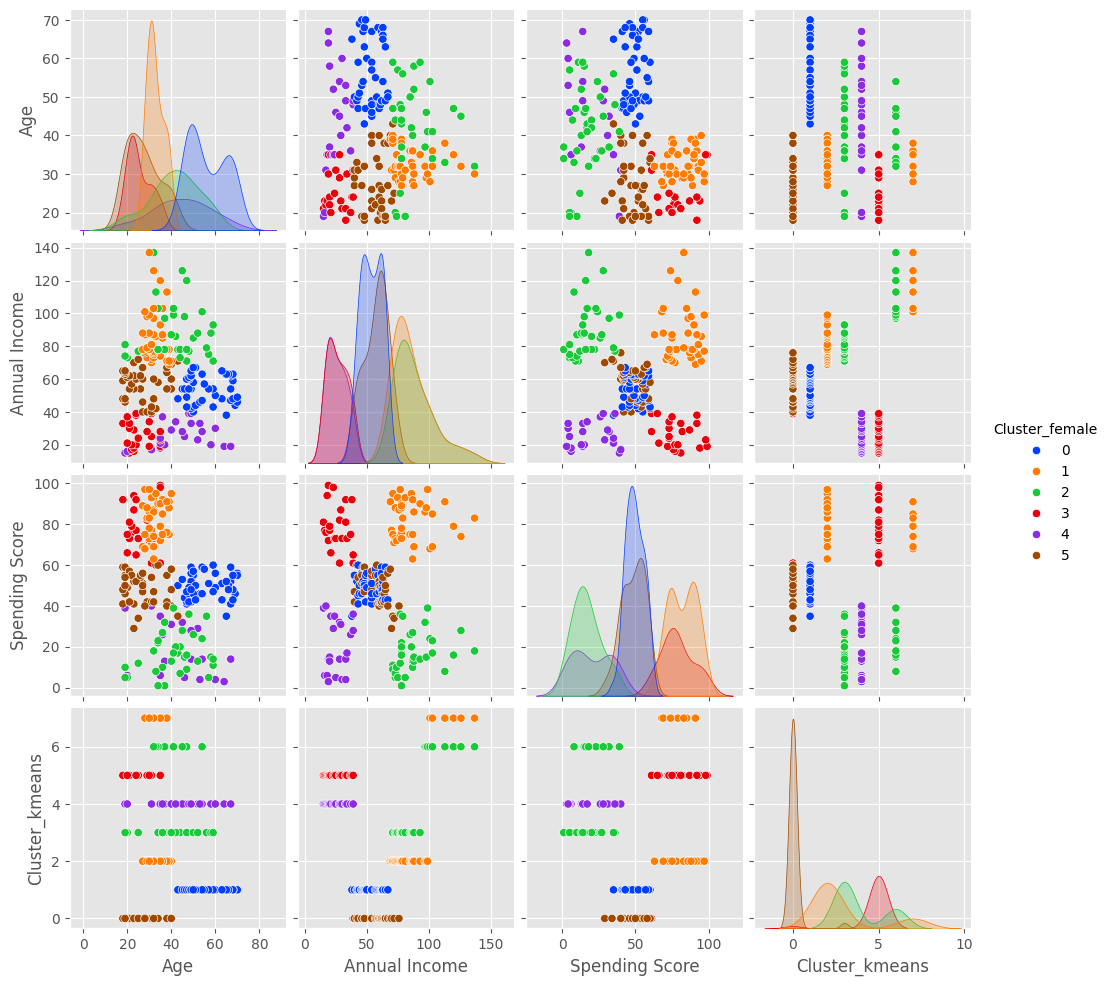

In [ ]:
if 'Cluster_female' not in df.columns:
	df['Cluster_female'] = kmeans_female.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

# Mostramos todas las combinaciones de variables en 2D
sb.pairplot(df, hue='Cluster_female', diag_kind='kde', palette='bright')
plt.show()

### Creación de clusters (male)

In [216]:
kmeans_male = KMeans(n_clusters = 6).fit(df_male)
centroids_male = kmeans_male.cluster_centers_

### Visualización en 3D (male)

In [217]:
df_male['Cluster_male'] = kmeans.fit_predict(df_male[['Age', 'Annual Income', 'Spending Score']])

# Define los colores para cada cluster
colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'brown', 'orange']

fig_male = go.Figure()

# Scatter plot para cada cluster
for i in df_male['Cluster_male'].unique():
  df_cluster = df_male[df_male['Cluster_male'] == i]
  fig_male.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

# Añade los centroides al gráfico
fig_male.add_trace(go.Scatter3d(
  x = centroids_male[:, 0], 
  y = centroids_male[:, 1], 
  z = centroids_male[:, 2], 
  mode = 'markers',
  marker = dict(
    size = 5,
    color = 'black',                
    opacity = 0.8
  ),
  name = 'Centroids'
))

fig_male.show()

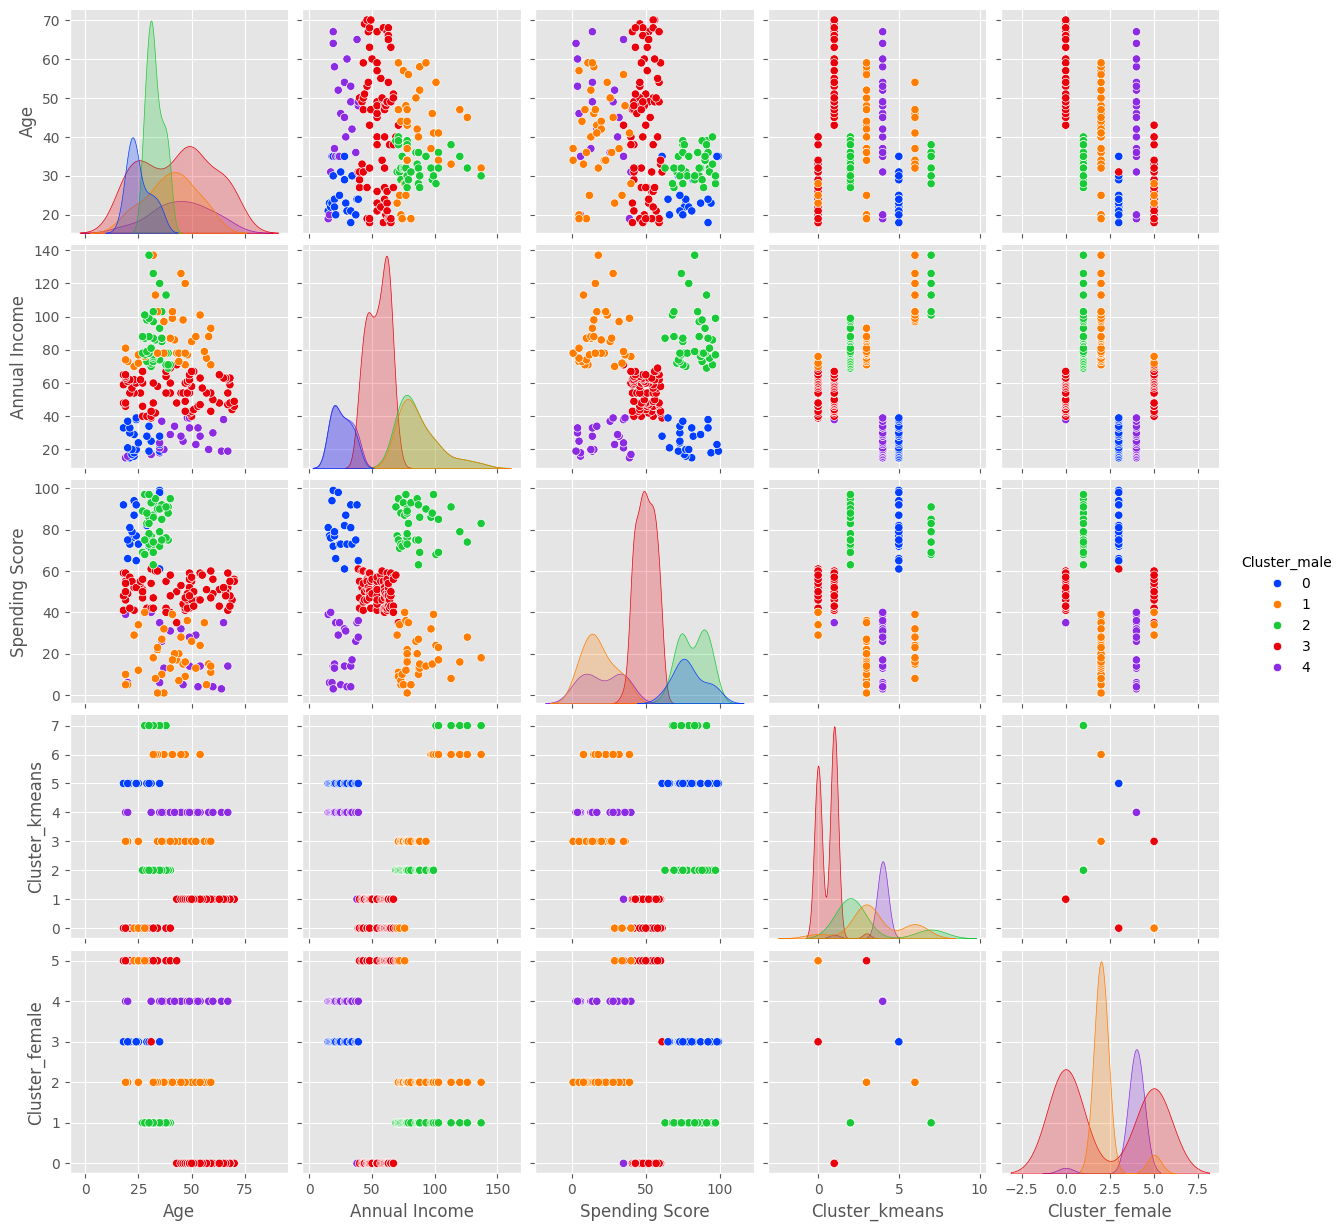

In [218]:
# Ensure the 'Cluster_female' column exists in the dataframe
if 'Cluster_male' not in df.columns:
	df['Cluster_male'] = kmeans_female.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

# Mostramos todas las combinaciones de variables en 2D
sb.pairplot(df, hue='Cluster_male', diag_kind='kde', palette='bright')
plt.show()